# **CÀI ĐẶT THƯ VIỆN**

In [ ]:
!pip install yfinance langchain_nvidia_ai_endpoints pyswarms tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.8/61.8 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 3.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
import pyswarms as ps
import matplotlib.pyplot as plt
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# **GET THE DATASET**

Tải dữ liệu lịch sử dài (benchmark) từ năm 2015-01-01 đến nay (hơn 11 năm, ~2800+ mẫu) — đủ dài để huấn luyện và đánh giá khoa học.

In [ ]:
import pandas as pd
import yfinance as yf
from datetime import datetime
import os
# ============= BENCHMARK DATASET UY TÍN =============
LOAI_VANG = "GC=F"
TEN_VANG = "XAUUSD"
FILENAME_CSV_BENCHMARK = "gia_vang_benchmark.csv"   # File benchmark dài
FILENAME_CSV_RECENT    = "gia_vang_yfinance.csv"     # File ngắn để real-time (nếu cần)

def lay_du_lieu_benchmark(start_date="2015-01-01"):
    """Tải benchmark dataset dài (2015 → nay) - Chuẩn cho nghiên cứu"""
    print(f"Đang tải BENCHMARK dataset XAU/USD từ {start_date} đến nay...")

    data = yf.download(LOAI_VANG, start=start_date, end=datetime.now().strftime("%Y-%m-%d"),
                       progress=False, auto_adjust=True)

    if data.empty:
        print("Không lấy được dữ liệu!")
        return None

    # Xử lý cột
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)

    df = pd.DataFrame({
        'Ngày giao dịch': data.index.strftime('%Y-%m-%d'),
        'Giá Đóng Cửa': data['Close'].round(2),
        'Giá Mở Cửa': data['Open'].round(2),
        'Giá Cao': data['High'].round(2),
        'Giá Thấp': data['Low'].round(2),
        'Khối lượng': data['Volume']
    }).reset_index(drop=True)

    df.to_csv(FILENAME_CSV_BENCHMARK, index=False, encoding='utf-8-sig')
    print(f"ĐÃ TẢI BENCHMARK THÀNH CÔNG!")
    print(f"   • Số ngày: {len(df):,} ngày")
    print(f"   • Từ: {df['Ngày giao dịch'].iloc[0]} → {df['Ngày giao dịch'].iloc[-1]}")
    print(f"   • File lưu: {FILENAME_CSV_BENCHMARK}")
    return df

# ============= (Tùy chọn) Lấy dữ liệu ngắn để real-time =============
def lay_du_lieu_ngan(so_ngay=30):
    """Chỉ dùng khi cần cập nhật dữ liệu mới nhất"""
    data = yf.download(LOAI_VANG, period=f"{so_ngay}d", progress=False)
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)
    df = pd.DataFrame({
        'Ngày giao dịch': data.index.strftime('%Y-%m-%d'),
        'Giá Đóng Cửa': data['Close'].round(2)
    })
    df.to_csv(FILENAME_CSV_RECENT, index=False, encoding='utf-8-sig')
    print(f"✅ Đã cập nhật {so_ngay} ngày gần nhất vào {FILENAME_CSV_RECENT}")
    return df

In [ ]:
# ============= TẢI BENCHMARK (chạy 1 lần) =============
df_benchmark = lay_du_lieu_benchmark("2015-01-01")

Đang tải BENCHMARK dataset XAU/USD từ 2015-01-01 đến nay...
ĐÃ TẢI BENCHMARK THÀNH CÔNG!
   • Số ngày: 2,829 ngày
   • Từ: 2015-01-02 → 2026-04-06
   • File lưu: gia_vang_benchmark.csv


In [ ]:
print(df_benchmark)

     Ngày giao dịch  Giá Đóng Cửa  Giá Mở Cửa  Giá Cao  Giá Thấp  Khối lượng
0        2015-01-02        1186.0      1184.0   1194.5    1169.5         138
1        2015-01-05        1203.9      1180.3   1206.9    1180.1         470
2        2015-01-06        1219.3      1203.5   1220.0    1203.5          97
3        2015-01-07        1210.6      1219.2   1219.2    1210.6          29
4        2015-01-08        1208.4      1207.0   1215.7    1206.3          92
...             ...           ...         ...      ...       ...         ...
2824     2026-03-30        4526.0      4482.8   4579.1    4413.4       10816
2825     2026-03-31        4647.6      4510.0   4684.1    4508.6        4264
2826     2026-04-01        4783.2      4668.4   4789.1    4668.0        1637
2827     2026-04-02        4651.5      4764.9   4784.4    4558.9           0
2828     2026-04-06        4656.8      4656.1   4689.6    4605.0           0

[2829 rows x 6 columns]


# Chuẩn bị dữ liệu & Hàm tạo dataset

In [ ]:
# Load dữ liệu từ file CSV
df = pd.read_csv('gia_vang_benchmark.csv')
df['Ngày giao dịch'] = pd.to_datetime(df['Ngày giao dịch'])
df = df.sort_values('Ngày giao dịch').reset_index(drop=True)

prices = df['Giá Đóng Cửa'].values.reshape(-1, 1)

# Chuẩn hóa
scaler = MinMaxScaler(feature_range=(0, 1))
prices_scaled = scaler.fit_transform(prices)

def create_dataset(data, look_back=60):
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i:(i + look_back), 0])
        y.append(data[i + look_back, 0])
    return np.array(X), np.array(y)

In [ ]:
print(f"Tổng số ngày dữ liệu: {len(df)}")

Tổng số ngày dữ liệu: 2829


# Xây dựng mô hình LSTM

In [ ]:
def build_lstm(look_back, hidden_units, learning_rate):
    model = Sequential()
    model.add(LSTM(units=hidden_units, input_shape=(look_back, 1)))
    model.add(Dense(1))
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mean_squared_error')
    return model

# Hàm mục tiêu cho PSO

In [ ]:
def objective_function(x):
    fitness = []
    for particle in x:
        look_back     = max(10, min(100, int(particle[0])))
        hidden_units  = max(30, min(200, int(particle[1])))
        learning_rate = max(0.0001, min(0.01, particle[2]))
        batch_size    = max(8, min(128, int(particle[3])))

        try:
            train_size = int(len(prices_scaled) * 0.8)
            X_train, y_train = create_dataset(prices_scaled[:train_size], look_back)
            X_test,  y_test  = create_dataset(prices_scaled[train_size:], look_back)

            X_train = X_train.reshape((X_train.shape[0], look_back, 1))
            X_test  = X_test.reshape((X_test.shape[0], look_back, 1))

            model = build_lstm(look_back, hidden_units, learning_rate)
            model.fit(X_train, y_train, epochs=15, batch_size=batch_size, verbose=0)

            pred_scaled = model.predict(X_test, verbose=0)
            pred = scaler.inverse_transform(pred_scaled)
            y_true = scaler.inverse_transform(y_test.reshape(-1, 1))

            rmse = np.sqrt(mean_squared_error(y_true, pred))
            fitness.append(rmse)
        except:
            fitness.append(10000)
    return np.array(fitness)

# Chạy PSO tối ưu siêu tham số

In [ ]:
print("Đang chạy PSO tối ưu siêu tham số cho LSTM...")

bounds = ([10, 30, 0.0001, 8], [100, 200, 0.01, 128])
options = {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
optimizer = ps.single.GlobalBestPSO(n_particles=15, dimensions=4, options=options, bounds=bounds)
cost, pos = optimizer.optimize(objective_function, iters=10)

print(f"\nPSO HOÀN THÀNH!")
print(f"RMSE tốt nhất: {cost:.4f}")
print(f"Look_back     : {int(pos[0])}")
print(f"Hidden units  : {int(pos[1])}")
print(f"Learning rate : {pos[2]:.5f}")
print(f"Batch size    : {int(pos[3])}")

2026-04-07 12:54:32,860 - pyswarms.single.global_best - INFO - Optimize for 10 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}


Đang chạy PSO tối ưu siêu tham số cho LSTM...


pyswarms.single.global_best: 100%|██████████|10/10, best_cost=67.5
2026-04-07 13:49:06,872 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 67.53902843696851, best pos: [2.30823685e+01 9.02952691e+01 9.44098340e-03 5.52262334e+01]



PSO HOÀN THÀNH!
RMSE tốt nhất: 67.5390
Look_back     : 23
Hidden units  : 90
Learning rate : 0.00944
Batch size    : 55


# Huấn luyện mô hình cuối cùng & Đánh giá

In [ ]:
# Siêu tham số tốt nhất
best_look_back = int(pos[0])
best_hidden    = int(pos[1])
best_lr        = pos[2]
best_batch     = int(pos[3])

# Chuẩn bị dữ liệu cuối
train_size = int(len(prices_scaled) * 0.8)
X_train, y_train = create_dataset(prices_scaled[:train_size], best_look_back)
X_test,  y_test  = create_dataset(prices_scaled[train_size:], best_look_back)

X_train = X_train.reshape((X_train.shape[0], best_look_back, 1))
X_test  = X_test.reshape((X_test.shape[0], best_look_back, 1))

final_model = build_lstm(best_look_back, best_hidden, best_lr)

print("Huấn luyện mô hình PSO-LSTM cuối cùng...")
final_model.fit(X_train, y_train, epochs=50, batch_size=best_batch, verbose=1)

# Dự đoán
pred_scaled = final_model.predict(X_test, verbose=0)
pred = scaler.inverse_transform(pred_scaled)
y_true = scaler.inverse_transform(y_test.reshape(-1, 1))

# Đánh giá
mae  = mean_absolute_error(y_true, pred)
rmse = np.sqrt(mean_squared_error(y_true, pred))
r2   = r2_score(y_true, pred)

print("\n" + "="*60)
print("📈 KẾT QUẢ ĐÁNH GIÁ PSO-LSTM")
print("="*60)
print(f"MAE  : {mae:.2f} USD")
print(f"RMSE : {rmse:.2f} USD")
print(f"R²   : {r2:.4f}")
print("="*60)

Huấn luyện mô hình PSO-LSTM cuối cùng...
Epoch 1/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0012
Epoch 2/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 3.5592e-05
Epoch 3/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 2.8477e-05
Epoch 4/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 2.5645e-05
Epoch 5/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 2.3796e-05
Epoch 6/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 2.3866e-05
Epoch 7/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 2.2844e-05
Epoch 8/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 2.3564e-05
Epoch 9/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 2.9999e-05
Epoch 10/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 2.3031e-05
Epoch 11/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 2.1583e-05
Epoch 12/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 2.1259e-05
Epoch 13/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 2.2899e-05
Epoch 14/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/st

# Vẽ biểu đồ dự đoán

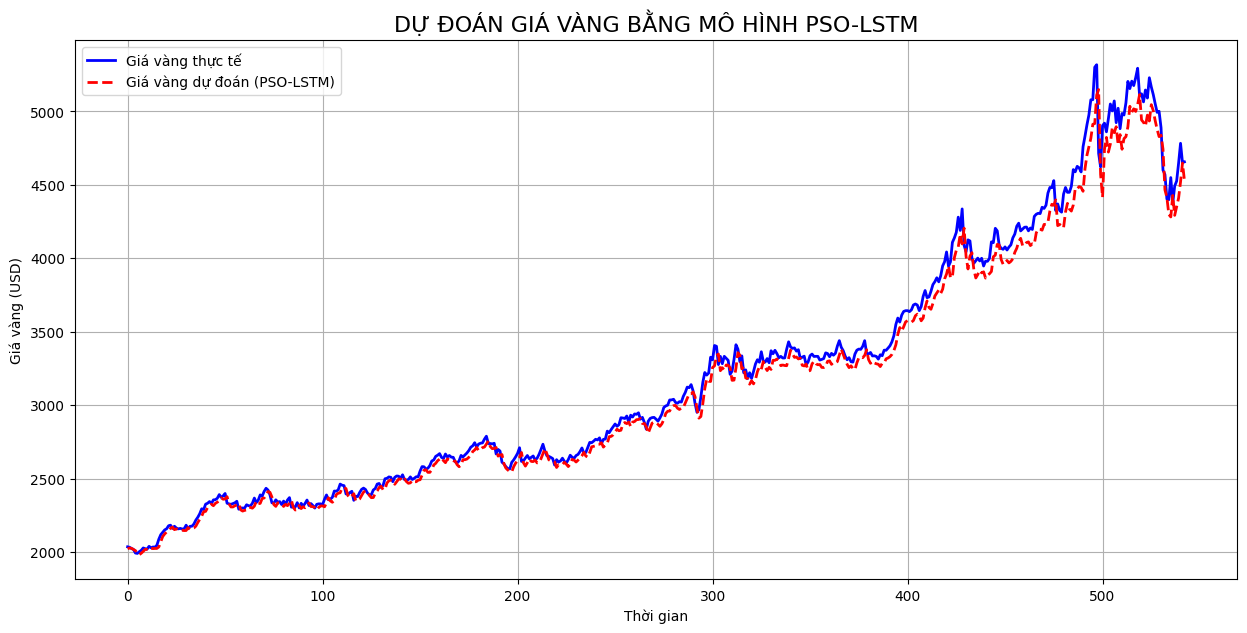

2026-04-07 13:49:59,245 - absl - WARNING - You are saving your model as an HDF5 file via `model.save()` or `keras.saving.save_model(model)`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')` or `keras.saving.save_model(model, 'my_model.keras')`. 


Đã lưu mô hình: model_PSO_LSTM_final.h5


In [ ]:
plt.figure(figsize=(15, 7))
plt.plot(y_true, label='Giá vàng thực tế', color='blue', linewidth=2)
plt.plot(pred, label='Giá vàng dự đoán (PSO-LSTM)', color='red', linestyle='--', linewidth=2)
plt.title('DỰ ĐOÁN GIÁ VÀNG BẰNG MÔ HÌNH PSO-LSTM', fontsize=16)
plt.xlabel('Thời gian')
plt.ylabel('Giá vàng (USD)')
plt.legend()
plt.grid(True)
plt.show()

final_model.save('model_PSO_LSTM_final.h5')
print("Đã lưu mô hình: model_PSO_LSTM_final.h5")